In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import sys
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from scipy.ndimage import distance_transform_edt
import time

# Enable GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Using GPU: {gpus[0].name}')
else:
    print('Using CPU')

print(f'TensorFlow version: {tf.__version__}')
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


2026-03-24 01:03:09.425140: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-24 01:03:09.425238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-24 01:03:09.439701: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using GPU: /physical_device:GPU:0
TensorFlow version: 2.15.1
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4070 Ti, compute capability 8.9


In [2]:
# Load TucoDataset from compiled .pyc
_pyc_dir = os.path.abspath(os.path.join('..', '__pycache__'))

def _load_pyc(name):
    pyc = os.path.join(_pyc_dir, f'{name}.cpython-310.pyc')
    spec = importlib.util.spec_from_file_location(name, pyc)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    sys.modules[name] = mod

_load_pyc('tuco_dataset')

from tuco_dataset import TucoDataset

DOWNSAMPLE = True
DATA_ROOT = '../../Data/Tuco'
MAX_TRAIN = 100
MAX_VAL = None
WINDOW_RADIUS = 3
N_STACK = 2 * WINDOW_RADIUS + 1

def _load_volumes(split, max_n):
    ds = TucoDataset(DATA_ROOT, split=split)
    if max_n is not None:
        from torch.utils.data import Subset
        ds = Subset(ds, range(min(max_n, len(ds))))
    mr_list, ct_list, mr_seg_list, ct_seg_list = [], [], [], []
    for sample in ds:
        mr_list.append(sample['moving'].squeeze(0).numpy().astype(np.float32))
        ct_list.append(sample['fixed'].squeeze(0).numpy().astype(np.float32))
        mr_seg_list.append(sample['moving_seg'].squeeze(0).numpy().astype(np.int16))
        ct_seg_list.append(sample['fixed_seg'].squeeze(0).numpy().astype(np.int16))
    return mr_list, ct_list, mr_seg_list, ct_seg_list

print('Loading train volumes...')
train_mr_vols, train_ct_vols, train_mr_segs, train_ct_segs = _load_volumes('train', MAX_TRAIN)
print('Loading val volumes...')
val_mr_vols, val_ct_vols, val_mr_segs, val_ct_segs = _load_volumes('val', MAX_VAL)

if DOWNSAMPLE:
    ORIENT_CONFIG = [
        (0, 96,  'axial',    (112, 96)),
        (1, 112, 'coronal',  (96,  96)),
        (2, 96,  'sagittal', (96,  112)),
    ]
else:
    ORIENT_CONFIG = [
        (0, 176, 'axial',    (208, 192)),
        (1, 208, 'coronal',  (176, 192)),
        (2, 192, 'sagittal', (176, 208)),
    ]

SEG_LABELS = [2, 3, 4, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 26, 28]
N_LABELS = len(SEG_LABELS)

n_train = len(train_mr_vols)
stacks_per_subj = sum(d - 2*WINDOW_RADIUS for _, d, _, _ in ORIENT_CONFIG)
print(f'Train: {n_train} subjects x {stacks_per_subj} stacks/subj = {n_train * stacks_per_subj} total')
print(f'Val: {len(val_mr_vols)} subjects')
print(f'{N_LABELS} anatomical labels')

Loading train volumes...
Found 144 volume pairs for split 'train'
Loading val volumes...
Found 18 volume pairs for split 'val'
Train: 100 subjects x 286 stacks/subj = 28600 total
Val: 18 subjects
16 anatomical labels


In [3]:
def multi_orient_generator(mr_vols, ct_vols, mr_segs, ct_segs,
                           batch_size=8, window_radius=WINDOW_RADIUS):
    # Cross-subject, multi-orientation slice-stack generator
    n_subj = len(mr_vols)
    wr = window_radius
    n_stack = 2 * wr + 1

    def _extract_slice(vol, axis, z):
        if axis == 0: return vol[z]
        elif axis == 1: return vol[:, z, :]
        else: return vol[:, :, z]

    def _extract_stack(vol, axis, z):
        if axis == 0: return vol[z-wr : z+wr+1]
        elif axis == 1: return vol[:, z-wr : z+wr+1, :].transpose(1, 0, 2)
        else: return vol[:, :, z-wr : z+wr+1].transpose(2, 0, 1)

    while True:
        axis, D, _, (H, W) = ORIENT_CONFIG[np.random.randint(3)]

        mr_subj_idx = np.random.randint(0, n_subj, size=batch_size)
        ct_subj_idx = np.random.randint(0, n_subj, size=batch_size)
        for k in range(batch_size):
            while ct_subj_idx[k] == mr_subj_idx[k]:
                ct_subj_idx[k] = np.random.randint(0, n_subj)

        z_idx = np.random.randint(wr, D - wr, size=batch_size)

        mr_batch, ct_batch = [], []
        mr_seg_batch, ct_seg_batch = [], []
        for sm, sc, z in zip(mr_subj_idx, ct_subj_idx, z_idx):
            mr_batch.append(np.ascontiguousarray(_extract_stack(mr_vols[sm], axis, z)))
            ct_batch.append(np.ascontiguousarray(_extract_stack(ct_vols[sc], axis, z)))
            mr_seg_batch.append(_extract_slice(mr_segs[sm], axis, z))
            ct_seg_batch.append(_extract_slice(ct_segs[sc], axis, z))

        # TensorFlow format: (B, H, W, C) - transpose from (B, C, H, W)
        mr_stack = np.stack(mr_batch).transpose(0, 2, 3, 1).astype(np.float32)  # (B, H, W, 7)
        ct_stack = np.stack(ct_batch).transpose(0, 2, 3, 1).astype(np.float32)
        mr_seg = np.stack(mr_seg_batch).astype(np.int32)  # (B, H, W)
        ct_seg = np.stack(ct_seg_batch).astype(np.int32)

        yield (mr_stack, ct_stack, mr_seg, ct_seg)

# Test generator
test_gen = multi_orient_generator(train_mr_vols, train_ct_vols,
                                   train_mr_segs, train_ct_segs, batch_size=2)
mr, ct, mrs, cts = next(test_gen)
print(f"Batch shapes: mr={mr.shape}, ct={ct.shape}, mr_seg={mrs.shape}, ct_seg={cts.shape}")
del test_gen, mr, ct, mrs, cts

Batch shapes: mr=(2, 208, 192, 7), ct=(2, 208, 192, 7), mr_seg=(2, 208, 192), ct_seg=(2, 208, 192)


In [4]:
def build_vxm_2p5d_tf(n_stack, enc_feats=(16, 32, 32, 32), final_feats=(32, 16), flow_scale=0.1):
    # Build 2.5D VoxelMorph model with FPGA-compatible flow scaling
    
    moving_stack = layers.Input(shape=(None, None, n_stack), name='moving_stack')
    fixed_stack = layers.Input(shape=(None, None, n_stack), name='fixed_stack')
    
    x = layers.Concatenate(axis=-1, name='concat')([moving_stack, fixed_stack])
    
    skips = []
    for i, nf in enumerate(enc_feats):
        x = layers.Conv2D(nf, 3, padding='same', kernel_initializer='he_normal', name=f'enc{i}_conv', use_bias=False)(x)
        x = layers.BatchNormalization(name=f'enc{i}_bn')(x)
        x = layers.LeakyReLU(alpha=0.1, name=f'enc{i}_act')(x)
        skips.append(x)
        
        x = layers.Conv2D(nf, 3, strides=2, padding='same', kernel_initializer='he_normal', name=f'enc{i}_ds_conv', use_bias=False)(x)
        x = layers.BatchNormalization(name=f'enc{i}_ds_bn')(x)
        x = layers.LeakyReLU(alpha=0.1, name=f'enc{i}_ds_act')(x)
    
    x = layers.Conv2D(enc_feats[-1], 3, padding='same', kernel_initializer='he_normal', name='bottleneck_conv', use_bias=False)(x)
    x = layers.BatchNormalization(name='bottleneck_bn')(x)
    x = layers.LeakyReLU(alpha=0.1, name='bottleneck_act')(x)
    
    for i, skip_ch in enumerate(reversed(enc_feats)):
        x = layers.UpSampling2D(size=2, interpolation='nearest', name=f'dec{i}_upsample')(x)
        skip = skips[-(i+1)]
        x = layers.Concatenate(axis=-1, name=f'dec{i}_concat')([x, skip])
        x = layers.Conv2D(skip_ch, 3, padding='same', kernel_initializer='he_normal', name=f'dec{i}_conv', use_bias=False)(x)
        x = layers.BatchNormalization(name=f'dec{i}_bn')(x)
        x = layers.LeakyReLU(alpha=0.1, name=f'dec{i}_act')(x)
    
    x = layers.Conv2D(final_feats[0], 3, padding='same', kernel_initializer='he_normal', name='final_conv0', use_bias=False)(x)
    x = layers.BatchNormalization(name='final_conv0_bn')(x)
    x = layers.LeakyReLU(alpha=0.1, name='final_conv0_act')(x)
    
    x = layers.Conv2D(final_feats[1], 3, padding='same', kernel_initializer='he_normal', name='final_conv1', use_bias=False)(x)
    x = layers.BatchNormalization(name='final_conv1_bn')(x)
    x = layers.LeakyReLU(alpha=0.1, name='final_conv1_act')(x)
    
    # Flow prediction layer (unscaled)
    flow_unscaled = layers.Conv2D(2, 3, padding='same', 
                                   kernel_initializer='zeros', 
                                   bias_initializer='zeros', 
                                   name='flow_unscaled')(x)
    
    # FPGA-compatible scaling using 1x1 conv with fixed weights
    flow_scaled = layers.Conv2D(2, 1, padding='same',
                                use_bias=False,
                                trainable=False,
                                kernel_initializer=tf.keras.initializers.Constant(flow_scale),
                                name='flow_scale', dtype='float32')(flow_unscaled)
    
    model = models.Model(inputs=[moving_stack, fixed_stack], outputs=flow_scaled, name='vxm_2p5d_tf_scaled')
    
    # Set the scaling layer weights and freeze it
    scale_layer = model.get_layer('flow_scale')
    scale_weights = np.zeros((1, 1, 2, 2), dtype=np.float32)
    scale_weights[0, 0, 0, 0] = flow_scale  # X channel
    scale_weights[0, 0, 1, 1] = flow_scale  # Y channel
    scale_layer.set_weights([scale_weights])
    scale_layer.trainable = False
    
    print(f"\nModel built with flow_scale={flow_scale}")
    print(f"  Unscaled flow range: ±20 pixels")
    print(f"  Scaled flow range: ±{20*flow_scale:.1f} pixels")
    print(f"  INT8 with scale=64 can represent: ±2 pixels")
    print(f"  This should fit with <5% clipping\n")
    
    return model


# Build model with 0.1 scaling for FPGA compatibility
model = build_vxm_2p5d_tf(N_STACK, flow_scale=0.1)
model.summary()


Model built with flow_scale=0.1
  Unscaled flow range: ±20 pixels
  Scaled flow range: ±2.0 pixels
  INT8 with scale=64 can represent: ±2 pixels
  This should fit with <5% clipping

Model: "vxm_2p5d_tf_scaled"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 moving_stack (InputLayer)   [(None, None, None, 7)]      0         []                            
                                                                                                  
 fixed_stack (InputLayer)    [(None, None, None, 7)]      0         []                            
                                                                                                  
 concat (Concatenate)        (None, None, None, 14)       0         ['moving_stack[0][0]',        
                                                                     'fixed_stack[0][0]']       

In [5]:
def bilinear_sample(img, x, y):
    H = tf.shape(img)[1]
    W = tf.shape(img)[2]
    
    max_y = tf.cast(H - 1, tf.float32)
    max_x = tf.cast(W - 1, tf.float32)
    
    x = tf.clip_by_value(x, 0.0, max_x)
    y = tf.clip_by_value(y, 0.0, max_y)
    
    x0 = tf.cast(tf.floor(x), tf.int32)
    x1 = x0 + 1
    y0 = tf.cast(tf.floor(y), tf.int32)
    y1 = y0 + 1
    
    x0 = tf.clip_by_value(x0, 0, W - 1)
    x1 = tf.clip_by_value(x1, 0, W - 1)
    y0 = tf.clip_by_value(y0, 0, H - 1)
    y1 = tf.clip_by_value(y1, 0, H - 1)
    
    batch_idx = tf.range(tf.shape(img)[0])
    batch_idx = tf.reshape(batch_idx, [-1, 1, 1])
    b = tf.tile(batch_idx, [1, H, W])
    
    Ia = tf.gather_nd(img, tf.stack([b, y0, x0], -1))
    Ib = tf.gather_nd(img, tf.stack([b, y1, x0], -1))
    Ic = tf.gather_nd(img, tf.stack([b, y0, x1], -1))
    Id = tf.gather_nd(img, tf.stack([b, y1, x1], -1))
    
    x0_f = tf.cast(x0, tf.float32)
    x1_f = tf.cast(x1, tf.float32)
    y0_f = tf.cast(y0, tf.float32)
    y1_f = tf.cast(y1, tf.float32)
    
    wa = (x1_f - x) * (y1_f - y)
    wb = (x1_f - x) * (y - y0_f)
    wc = (x - x0_f) * (y1_f - y)
    wd = (x - x0_f) * (y - y0_f)
    
    wa = tf.expand_dims(wa, -1)
    wb = tf.expand_dims(wb, -1)
    wc = tf.expand_dims(wc, -1)
    wd = tf.expand_dims(wd, -1)
    
    return wa * Ia + wb * Ib + wc * Ic + wd * Id


def spatial_transform_2d(src, flow):
    batch_size = tf.shape(src)[0]
    height = tf.shape(src)[1]
    width = tf.shape(src)[2]
    
    y_grid, x_grid = tf.meshgrid(
        tf.range(height, dtype=tf.float32),
        tf.range(width, dtype=tf.float32),
        indexing='ij'
    )
    y_grid = tf.expand_dims(y_grid, 0)
    x_grid = tf.expand_dims(x_grid, 0)
    y_grid = tf.tile(y_grid, [batch_size, 1, 1])
    x_grid = tf.tile(x_grid, [batch_size, 1, 1])
    
    x_new = x_grid + flow[..., 0]
    y_new = y_grid + flow[..., 1]
    
    return bilinear_sample(src, x_new, y_new)


def flow_gradient_loss(flow):
    dx = flow[:, :, 1:, :] - flow[:, :, :-1, :]
    dy = flow[:, 1:, :, :] - flow[:, :-1, :, :]
    
    dx_padded = tf.pad(dx, [[0, 0], [0, 0], [0, 1], [0, 0]])
    dy_padded = tf.pad(dy, [[0, 0], [0, 1], [0, 0], [0, 0]])
    
    return tf.reduce_mean(tf.square(dx_padded)) + tf.reduce_mean(tf.square(dy_padded))


def seg_to_onehot(seg, labels=SEG_LABELS):
    seg_int = tf.cast(seg, tf.int32)
    onehot_list = []
    
    for label in labels:
        onehot_list.append(tf.cast(tf.equal(seg_int, label), tf.float32))
    
    return tf.stack(onehot_list, axis=-1)


def dice_loss(pred_onehot, gt_onehot, eps=1e-5):
    intersection = tf.reduce_sum(pred_onehot * gt_onehot, axis=[1, 2])
    union = tf.reduce_sum(pred_onehot, axis=[1, 2]) + tf.reduce_sum(gt_onehot, axis=[1, 2])
    
    dice_per_label = (2.0 * intersection + eps) / (union + eps)
    return 1.0 - tf.reduce_mean(dice_per_label)


print("Loss functions defined")

Loss functions defined


In [6]:
BATCH_SIZE = 16
MI_WEIGHT = 0.5
STEPS_PER_EPOCH = 200
VAL_STEPS = 50
EPOCHS = 800
SMOOTH_WEIGHT = 0.1
CKPT_EVERY = 100

SAVE_DIR = '../trained_weights'
CKPT_DIR = os.path.join(SAVE_DIR, '2p5d_tf_checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, '2p5d_dense_tf_best.h5')
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, '2p5d_dense_tf.h5')

optimizer = keras.optimizers.Adam(learning_rate=1e-4)
optimizer = mixed_precision.LossScaleOptimizer(optimizer)

model.compile(optimizer=optimizer)

train_gen = multi_orient_generator(train_mr_vols, train_ct_vols,
                                    train_mr_segs, train_ct_segs,
                                    batch_size=BATCH_SIZE)

print('Pre-computing fixed validation batches...')
_val_gen = multi_orient_generator(val_mr_vols, val_ct_vols,
                                   val_mr_segs, val_ct_segs,
                                   batch_size=BATCH_SIZE)
val_batches = []
for _ in range(VAL_STEPS):
    val_batches.append(next(_val_gen))
del _val_gen
print(f'{len(val_batches)} fixed val batches cached')

train_history = []
val_history = []
best_loss = float('inf')

print(f'\nTraining: {STEPS_PER_EPOCH} steps/epoch, {EPOCHS} epochs')
print(f'Loss: Dice + {SMOOTH_WEIGHT} x smooth | Cross-subject | Multi-orientation')
print(f'Batch size: {BATCH_SIZE}')

Pre-computing fixed validation batches...
50 fixed val batches cached

Training: 200 steps/epoch, 800 epochs
Loss: Dice + 0.1 x smooth | Cross-subject | Multi-orientation
Batch size: 16


In [7]:

class PatchwiseMI:
    def __init__(self, num_bins=32, sigma_ratio=0.5, max_clip=1.0):
        self.num_bins = num_bins
        bin_centers = np.linspace(0, max_clip, num_bins).astype(np.float32)
        self.bin_centers = tf.constant(bin_centers, dtype=tf.float32)
        sigma = np.mean(np.diff(bin_centers)) * sigma_ratio
        self.preterm = tf.constant(1.0 / (2 * (sigma ** 2)), dtype=tf.float32)
        self.max_clip = max_clip

    def _soft_encoding(self, vol):
        vol = tf.clip_by_value(vol, 0.0, self.max_clip)
        vol = tf.expand_dims(vol, -1)
        bin_centers = tf.reshape(self.bin_centers, [1, 1, 1, 1, self.num_bins])
        diff = tf.cast(vol, tf.float32) - bin_centers
        enc = tf.exp(-self.preterm * tf.square(diff))
        enc = enc / (tf.reduce_sum(enc, axis=-1, keepdims=True) + 1e-8)
        return enc

    def __call__(self, I, J):
        B = tf.shape(I)[0]
        I_enc = self._soft_encoding(I)
        J_enc = self._soft_encoding(J)
        
        I_enc = tf.reshape(I_enc, [B, -1, self.num_bins])
        J_enc = tf.reshape(J_enc, [B, -1, self.num_bins])
        
        I_perm = tf.transpose(I_enc, perm=[0, 2, 1])
        pab = tf.matmul(I_perm, J_enc) / tf.cast(tf.shape(I_enc)[1], tf.float32)
        
        pa = tf.reduce_mean(I_enc, axis=1, keepdims=True)
        pb = tf.reduce_mean(J_enc, axis=1, keepdims=True)
        papb = tf.matmul(tf.transpose(pa, perm=[0, 2, 1]), pb) + 1e-8
        
        mi = tf.reduce_sum(pab * tf.math.log((pab + 1e-8) / papb), axis=[1, 2])
        return -tf.reduce_mean(mi)

patchwise_mi = PatchwiseMI()

def train_step(mr_stack, ct_stack, mr_seg, ct_seg):
    with tf.GradientTape() as tape:
        flow = model([mr_stack, ct_stack], training=True)
        smooth_loss = flow_gradient_loss(flow)
        
        mr_seg_oh = seg_to_onehot(mr_seg)
        ct_seg_oh = seg_to_onehot(ct_seg)
        warped_seg_oh = spatial_transform_2d(mr_seg_oh, flow)
        d_loss = dice_loss(warped_seg_oh, ct_seg_oh)
        
        mr_center = tf.expand_dims(mr_stack[..., WINDOW_RADIUS], -1)
        ct_center = tf.expand_dims(ct_stack[..., WINDOW_RADIUS], -1)
        # Spatial transformer operates on float32/16 based on inputs
        warped_mr_center = spatial_transform_2d(mr_center, flow)
        mi_loss_val = patchwise_mi(warped_mr_center, ct_center)
        
        total_loss = d_loss + MI_WEIGHT * mi_loss_val + SMOOTH_WEIGHT * smooth_loss
        scaled_loss = optimizer.get_scaled_loss(total_loss)
    
    scaled_gradients = tape.gradient(scaled_loss, model.trainable_variables)
    gradients = optimizer.get_unscaled_gradients(scaled_gradients)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return total_loss

def val_step(mr_stack, ct_stack, mr_seg, ct_seg):
    flow = model([mr_stack, ct_stack], training=False)
    smooth_loss = flow_gradient_loss(flow)
    
    mr_seg_oh = seg_to_onehot(mr_seg)
    ct_seg_oh = seg_to_onehot(ct_seg)
    warped_seg_oh = spatial_transform_2d(mr_seg_oh, flow)
    d_loss = dice_loss(warped_seg_oh, ct_seg_oh)
    
    mr_center = tf.expand_dims(mr_stack[..., WINDOW_RADIUS], -1)
    ct_center = tf.expand_dims(ct_stack[..., WINDOW_RADIUS], -1)
    warped_mr_center = spatial_transform_2d(mr_center, flow)
    mi_loss_val = patchwise_mi(warped_mr_center, ct_center)
        
    total_loss = d_loss + MI_WEIGHT * mi_loss_val + SMOOTH_WEIGHT * smooth_loss
    return total_loss



In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='keras')

for epoch in range(EPOCHS):
    running_train = 0.0
    nan_steps = 0
    
    for step in range(STEPS_PER_EPOCH):
        mr_stack, ct_stack, mr_seg, ct_seg = next(train_gen)
        
        loss = train_step(mr_stack, ct_stack, mr_seg, ct_seg)
        
        if tf.math.is_finite(loss):
            running_train += loss.numpy()
        else:
            nan_steps += 1
    
    valid_steps = STEPS_PER_EPOCH - nan_steps
    epoch_train = running_train / max(valid_steps, 1)
    train_history.append(epoch_train)
    
    running_val = 0.0
    for mr_v, ct_v, mrs_v, cts_v in val_batches:
        loss_v = val_step(mr_v, ct_v, mrs_v, cts_v)
        running_val += loss_v.numpy()
    
    epoch_val = running_val / len(val_batches)
    val_history.append(epoch_val)
    
    nan_str = f'  ({nan_steps} NaN)' if nan_steps else ''
    print(f'Epoch {epoch+1}/{EPOCHS} -- train: {epoch_train:.6f} | val: {epoch_val:.6f}{nan_str}')
    
    if (epoch + 1) % CKPT_EVERY == 0:
        ckpt_path = os.path.join(CKPT_DIR, f'2p5d_tf_epoch_{epoch+1}.h5')
        model.save(ckpt_path)
    
    if epoch_val < best_loss:
        best_loss = epoch_val
        model.save(BEST_MODEL_PATH)

model.save(FINAL_MODEL_PATH)

train_history = np.array(train_history, dtype=np.float32)
val_history = np.array(val_history, dtype=np.float32)
print(f'\nBest val loss: {best_loss:.6f}')
print(f'Training complete!')

I0000 00:00:1774310657.490295  181076 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


KeyboardInterrupt: 

: 

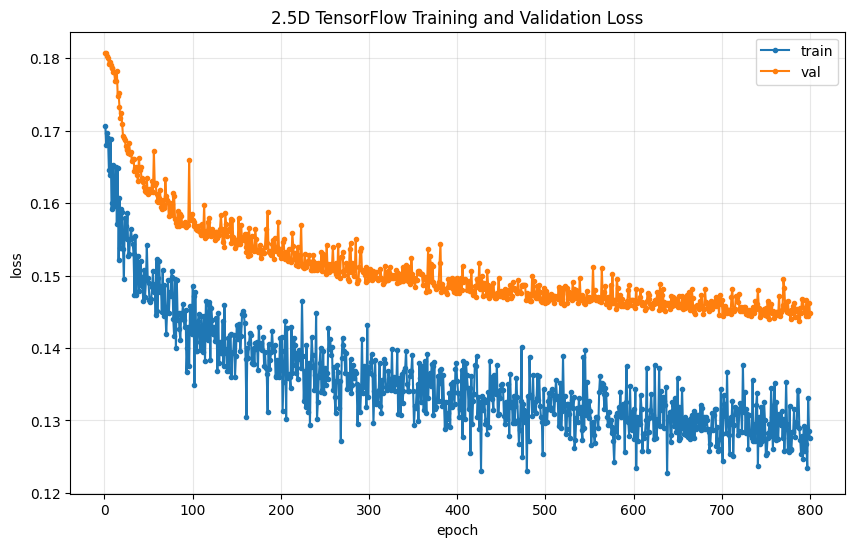

In [ ]:
epochs_ran = np.arange(1, len(train_history) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs_ran, train_history, '.-', label='train')
plt.plot(epochs_ran, val_history,   '.-', label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('2.5D TensorFlow Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def compute_dice_per_label(warped_seg, fixed_seg, labels=SEG_LABELS):
    dice_scores = []
    for lbl in labels:
        w = (warped_seg == lbl).astype(np.float32)
        f = (fixed_seg == lbl).astype(np.float32)
        inter = (w * f).sum()
        union = w.sum() + f.sum()
        dice_scores.append(1.0 if union == 0 else 2.0 * inter / union)
    return np.array(dice_scores)


def hausdorff_distance_95(seg1, seg2):
    if seg1.sum() == 0 and seg2.sum() == 0: return 0.0
    if seg1.sum() == 0 or seg2.sum() == 0: return np.inf
    dt2 = distance_transform_edt(~seg2.astype(bool))
    dt1 = distance_transform_edt(~seg1.astype(bool))
    d12 = dt2[seg1.astype(bool)]
    d21 = dt1[seg2.astype(bool)]
    return max(np.percentile(d12, 95), np.percentile(d21, 95))


def negative_jacobian_ratio_2d(flow_np):
    H, W, _ = flow_np.shape
    grid_h, grid_w = np.mgrid[:H, :W].astype(np.float32)
    deform = flow_np.copy()
    deform[..., 0] += grid_h
    deform[..., 1] += grid_w
    d00 = np.gradient(deform[..., 0], axis=0)
    d01 = np.gradient(deform[..., 0], axis=1)
    d10 = np.gradient(deform[..., 1], axis=0)
    d11 = np.gradient(deform[..., 1], axis=1)
    det = d00 * d11 - d01 * d10
    return np.sum(det <= 0) / det.size


def infer_volume_2p5d(model, mr_vol, ct_vol, axis=0, window_radius=WINDOW_RADIUS):
    # Run inference on a full volume
    wr = window_radius
    D = mr_vol.shape[axis]
    flows = []

    t0 = time.time()

    for z in range(wr, D - wr):
        if axis == 0:
            mr_stack = mr_vol[z-wr:z+wr+1]
            ct_stack = ct_vol[z-wr:z+wr+1]
        elif axis == 1:
            mr_stack = mr_vol[:, z-wr:z+wr+1, :].transpose(1, 0, 2)
            ct_stack = ct_vol[:, z-wr:z+wr+1, :].transpose(1, 0, 2)
        else:
            mr_stack = mr_vol[:, :, z-wr:z+wr+1].transpose(2, 0, 1)
            ct_stack = ct_vol[:, :, z-wr:z+wr+1].transpose(2, 0, 1)

        # TensorFlow format
        mr_input = mr_stack.transpose(1, 2, 0)[np.newaxis].astype(np.float32)
        ct_input = ct_stack.transpose(1, 2, 0)[np.newaxis].astype(np.float32)
        
        # Model returns SCALED flow (0.1x of real displacement)
        flow = model.predict([mr_input, ct_input], verbose=0)
        flows.append(flow[0])

    return np.stack(flows), time.time() - t0


# Load best model
model = keras.models.load_model(BEST_MODEL_PATH)

print("NOTE: Model outputs flow scaled by 0.1x for FPGA compatibility")
print("GPU evaluation uses scaled flow directly (losses are computed correctly)")
print("FPGA inference must multiply dequantized flow by 10.0\n")

n_val = len(val_mr_vols)
np.random.seed(42)
indices = np.random.permutation(n_val)
n_pairs = n_val // 2
pairings = [(indices[2*i], indices[2*i+1]) for i in range(n_pairs)]
print(f'{n_val} val subjects, {n_pairs} cross-subject pairs\n')

dice_all, hd95_all, jacobian_all, infer_times = [], [], [], []

for pair_idx, (i, j) in enumerate(pairings):
    print(f'  Pair {pair_idx+1}/{n_pairs}: subj {i} (MR) -> subj {j} (CT)')

    flow_stack, duration = infer_volume_2p5d(model, val_mr_vols[i], val_ct_vols[j], axis=0)
    if pair_idx > 0:
        infer_times.append(duration)

    wr = WINDOW_RADIUS
    D = val_mr_vols[i].shape[0]
    mr_seg = val_mr_segs[i]
    ct_seg = val_ct_segs[j]

    warped_labels = np.zeros_like(mr_seg)
    for si, z in enumerate(range(wr, D - wr)):
        flow_2d = flow_stack[si]  # (H, W, 2) - SCALED by 0.1
        
        # Warp segmentation using TensorFlow
        # spatial_transform_2d works with scaled flow directly
        seg_oh = seg_to_onehot(tf.constant(mr_seg[z][np.newaxis]))
        flow_t = tf.constant(flow_2d[np.newaxis])
        warped_oh = spatial_transform_2d(seg_oh, flow_t)
        warped_np = warped_oh[0].numpy()
        
        for li, lbl in enumerate(SEG_LABELS):
            warped_labels[z][warped_np[..., li] > 0.5] = lbl

    warped_eval = warped_labels[wr:D-wr]
    fixed_eval = ct_seg[wr:D-wr]

    dice_all.append(compute_dice_per_label(warped_eval, fixed_eval))

    hd95_per_label = []
    for lbl in SEG_LABELS:
        hd95_per_label.append(hausdorff_distance_95(
            (warped_eval == lbl).astype(np.uint8),
            (fixed_eval == lbl).astype(np.uint8)))
    hd95_all.append(np.mean(hd95_per_label))

    jac_ratios = [negative_jacobian_ratio_2d(flow_stack[si]) for si in range(flow_stack.shape[0])]
    jacobian_all.append(np.mean(jac_ratios))

dice_all = np.stack(dice_all)
dice_means = dice_all.mean(axis=1) * 100

print(f'\nAvg Dice: {dice_means.mean():.2f} +/- {dice_means.std():.2f} %')
print(f'|J| <= 0: {np.mean(jacobian_all):.6f} +/- {np.std(jacobian_all):.6f}')
print(f'HD95: {np.mean(hd95_all):.2f} +/- {np.std(hd95_all):.2f}')
if infer_times:
    print(f'Inference time: {np.mean(infer_times):.4f} +/- {np.std(infer_times):.4f} s')

print(f'\nPer-label Dice (mean +/- std across {n_pairs} pairs):')
for li, lbl in enumerate(SEG_LABELS):
    print(f'  Label {lbl:3d}: {dice_all[:, li].mean()*100:6.2f} +/- {dice_all[:, li].std()*100:5.2f} %')

NOTE: Model outputs flow scaled by 0.1x for FPGA compatibility
GPU evaluation uses scaled flow directly (losses are computed correctly)
FPGA inference must multiply dequantized flow by 10.0

18 val subjects, 9 cross-subject pairs

  Pair 1/9: subj 0 (MR) -> subj 1 (CT)
  Pair 2/9: subj 8 (MR) -> subj 5 (CT)
  Pair 3/9: subj 3 (MR) -> subj 13 (CT)
  Pair 4/9: subj 16 (MR) -> subj 15 (CT)
  Pair 5/9: subj 11 (MR) -> subj 2 (CT)
  Pair 6/9: subj 9 (MR) -> subj 17 (CT)
  Pair 7/9: subj 4 (MR) -> subj 12 (CT)
  Pair 8/9: subj 7 (MR) -> subj 10 (CT)
  Pair 9/9: subj 14 (MR) -> subj 6 (CT)

Avg Dice: 72.67 +/- 3.42 %
|J| <= 0: 0.001441 +/- 0.000363
HD95: 2.83 +/- 1.36
Inference time: 10.7169 +/- 0.4887 s

Per-label Dice (mean +/- std across 9 pairs):
  Label   2:  68.75 +/-  1.84 %
  Label   3:  57.88 +/-  1.78 %
  Label   4:  83.71 +/-  5.58 %
  Label   7:  75.16 +/-  2.14 %
  Label   8:  81.57 +/-  1.87 %
  Label  10:  82.29 +/-  3.79 %
  Label  11:  66.75 +/-  7.50 %
  Label  12:  70.77 +/